In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu
import sys
sys.path.insert(0, '/Users/bryan.carroll/Library/CloudStorage/GoogleDrive-bryan.carroll@wise.com/My Drive/BryWise/AI')
import wise_colours

df = pd.read_csv('Notif flags with crm.csv')
df.head()

In [2]:
bool_cols = ['TRANSFERS_EMAIL', 'TRANSFERS_PUSH', 'BALANCES_CARDS_EMAIL',
             'BALANCES_CARDS_PUSH', 'PROMOTIONAL_EMAIL', 'PROMOTIONAL_PUSH',
             'SURVEYS_EMAIL', 'CAMPAIGNS_EMAIL']
df[bool_cols] = df[bool_cols].fillna(False).astype(bool)

email_cols = ['TRANSFERS_EMAIL', 'BALANCES_CARDS_EMAIL', 'PROMOTIONAL_EMAIL',
              'SURVEYS_EMAIL', 'CAMPAIGNS_EMAIL']
other_cols = [c for c in bool_cols if c != 'SURVEYS_EMAIL']

# 1. Opted out of everything (all 8 channels off)
df['opted_out_all'] = ~df[bool_cols].any(axis=1)

# 2. Opted out of all emails (all 5 email channels off, but NOT everything off)
df['opted_out_all_email'] = ~df[email_cols].any(axis=1) & ~df['opted_out_all']

# 3. Surveys off + at least one other channel also off, but not all and not all email
df['opted_out_surveys_plus_but_not_all'] = (
    ~df['SURVEYS_EMAIL'] &
    (~df[other_cols]).any(axis=1) &
    ~df['opted_out_all'] &
    ~df['opted_out_all_email']
)

# 4. Surveys off, everything else still on
df['opted_out_only_surveys'] = (
    ~df['SURVEYS_EMAIL'] &
    df[other_cols].all(axis=1)
)

## What's going on with research email opt-outs?

**tl;dr**
1. At most, 20% of users are actually opting out from research outreach.
2. The current opt-out rate is likely inflated due to the notifications page design. Redesigning this page could ensure that new users aren't inadvertently opting out. Additional steps would be required to rectify the issue for the 25 - 70% of users for whom the intent is unclear
3. The Global Experimentation Framework has been excluding users from research outreach. This exclusion hit ~30% of opted-in users on average, and in some studies up to 90% depending on the segment. This was inadvertent - research should not have been included in this exclusion. This mistake has now been rectified
4. Outreach cooldown groups research outreach and marketing outreach as one, and makes users who have received outreach in the last 30 days ineligible. This impacts up to 50% of users. If research outreach was handled separately, this would come down to 5%. 

**The detail**
Researchers struggle to recruit and survey from users, as Braze filters substantially reduce eligible contacts. Upwards of 95% of target customers can be deemed ineligible to contact, but often that ineligibility is bundled into an opaque "email-eligibility" criteria.

Such high opt-out rates are problematic for UXR; it limits who we can speak to for qualitative research, makes quantitative research near impossible, and introduces tremendous bias into the results of any research we are able to do. 

There are two questions to answer:
1) Are Wise customers really so unwilling to receive research outreach and give feedback? This opt out rate is well above the industry norm
2) If not, what is the cause of the discrepancy between Braze's opt-out rate and what the users' opt-out intent?

## Question 1: Do Wise Customers Really Not Want to Give Feedback?

### Current opt-out rates
I took a sample of 1,000,000 users across UK, US, CA, FR, DE, and AUS and looked at the opt out preferences from the notifications screen.

Campaign email and cards & balances email have such high opt-out rate and so little variance it must be assumed these are default opt-in (somebody check me on this).

Nearly 20% opt out of Research Emails, essentially opting out at the same rate as Promotional Emails. It is unusual that these are nearly identical, suggesting something is up.



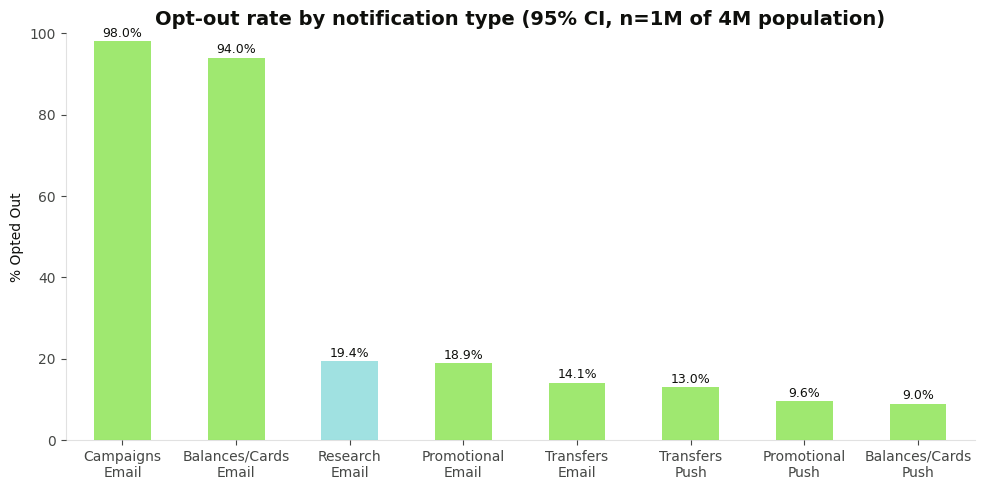

In [18]:
# Chart 1: Opt-out rate by notification type (sorted high to low)
notif_cols = {
    'Transfers\nEmail': 'TRANSFERS_EMAIL',
    'Transfers\nPush': 'TRANSFERS_PUSH',
    'Balances/Cards\nEmail': 'BALANCES_CARDS_EMAIL',
    'Balances/Cards\nPush': 'BALANCES_CARDS_PUSH',
    'Promotional\nEmail': 'PROMOTIONAL_EMAIL',
    'Promotional\nPush': 'PROMOTIONAL_PUSH',
    'Research\nEmail': 'SURVEYS_EMAIL',
    'Campaigns\nEmail': 'CAMPAIGNS_EMAIL',
}

# Sample is 1M drawn from a 4M population -> apply finite population correction
N_POP = 4_000_000
n_samp = len(df)
fpc = np.sqrt((N_POP - n_samp) / (N_POP - 1))

opt_out_rates = pd.Series({label: (~df[col]).mean() * 100 for label, col in notif_cols.items()})
opt_out_rates = opt_out_rates.sort_values(ascending=False)
# 95% CI half-width on a proportion, with FPC, in percentage points (same order as bars)
p = opt_out_rates / 100
ci95 = 1.96 * np.sqrt(p * (1 - p) / n_samp) * fpc * 100

colors = [wise_colours.BRIGHT_BLUE if 'Research' in label else wise_colours.BRIGHT_GREEN
          for label in opt_out_rates.index]

fig, ax = plt.subplots(figsize=(10, 5))
opt_out_rates.plot(kind='bar', ax=ax, color=colors,
                   #yerr=ci95.values, capsize=4,
                   #error_kw={'ecolor': '#333333', 'elinewidth': 1}
                   )
ax.set_ylabel('% Opted Out')
ax.set_xlabel('')
ax.set_title('Opt-out rate by notification type (95% CI, n=1M of 4M population)')
ax.set_ylim(0, 100)
for i, v in enumerate(opt_out_rates):
    ax.text(i, v + ci95.iloc[i] + 1, f'{v:.1f}%', ha='center', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# CI half-widths are tiny at this sample size — print exact values
#print("95% CI half-width (percentage points):")
#print(ci95.round(3).to_string())

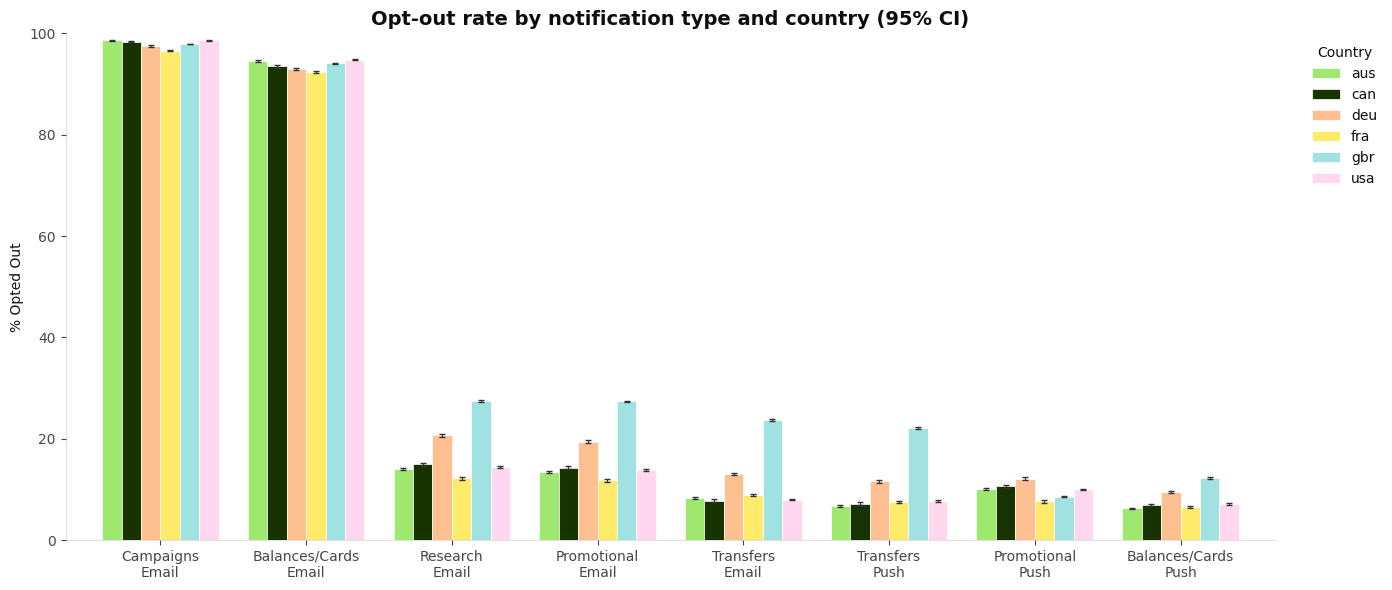

In [8]:
# Chart 1a: Opt-out rates by notification type, bars = country
notif_types = {
    'Transfers\nEmail': 'TRANSFERS_EMAIL',
    'Transfers\nPush': 'TRANSFERS_PUSH',
    'Balances/Cards\nEmail': 'BALANCES_CARDS_EMAIL',
    'Balances/Cards\nPush': 'BALANCES_CARDS_PUSH',
    'Promotional\nEmail': 'PROMOTIONAL_EMAIL',
    'Promotional\nPush': 'PROMOTIONAL_PUSH',
    'Research\nEmail': 'SURVEYS_EMAIL',
    'Campaigns\nEmail': 'CAMPAIGNS_EMAIL',
}

# Population ~4M, sampling fraction ~1/4 -> finite population correction.
# Per-country n is unknown in the population, so scale the overall fraction by
# each country's share of the sample (conservative: assumes same share in pop).
N_POP = 4_000_000
samp_frac = len(df) / N_POP

opt_out_by_country = pd.DataFrame({
    label: df.groupby('COUNTRY')[col].apply(lambda x: (~x).mean() * 100)
    for label, col in notif_types.items()
}).T  # transpose so rows = notification type, columns = country

# 95% CI half-widths (percentage points) per notif type x country
ci_by_country = pd.DataFrame({
    label: df.groupby('COUNTRY')[col].apply(
        lambda x: 1.96 * np.sqrt(((~x).mean() * (1 - (~x).mean())) / len(x))
        * np.sqrt(max((len(x)/samp_frac - len(x)) / (len(x)/samp_frac - 1), 0)) * 100
    )
    for label, col in notif_types.items()
}).T

# Sort notification types by overall opt-out rate (high to low)
opt_out_by_country['_mean'] = opt_out_by_country.mean(axis=1)
order_idx = opt_out_by_country.sort_values('_mean', ascending=False).index
opt_out_by_country = opt_out_by_country.loc[order_idx].drop(columns='_mean')
# Align CI to the same row/column order as the plotted data
ci_by_country = ci_by_country.loc[order_idx, opt_out_by_country.columns]

fig, ax = plt.subplots(figsize=(14, 6))
opt_out_by_country.plot(kind='bar', ax=ax, width=0.8,
                        color=wise_colours.CATEGORICAL[:len(opt_out_by_country.columns)],
                        edgecolor='white', linewidth=0.5,
                        yerr=ci_by_country, capsize=2,
                        error_kw={'ecolor': '#333333', 'elinewidth': 0.8})
ax.set_ylabel('% Opted Out')
ax.set_xlabel('')
ax.set_title('Opt-out rate by notification type and country (95% CI)')
ax.set_ylim(0, 100)
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Breaking this down by country, the main takeaway from this is that GBR is a pretty big outlier in the opt outs. We should bear that in mind when doing research in the UK.

These opt out rates are pretty high - 20% on average, up to 35% in the UK. To be fair, this is higher than I expected. But, even still this is nowhere near the opt-out rates that Braze reports.

## Quesiton 2: What could cause the discrepancy between user opt-out intent and our reported opt-out rates?
Users can opt-out from receiving research outreach through Settings -> Notifications -> Notifications path. 

The notifications screen has a master toggle to allow notifications at all, and then groups different types of notifications. 

Invitations to share feedback is included on this page, below the fold. 

[insert screenshot here]

This is a potentially severe design problem that may be having an unintended effect of opting people out of research without true intent to do so. 

There are two methods through which this could happen:

1) The user toggles off "Allow notifications", without even realising that they have opted out of research
2) The user quickly quickly toggles off all email channels, assuming these are all of a similar nature


Looking at just the people who opted out of research emails, we can break these into four buckets:
1) People who opted out of ONLY research emails (clear signal of intent)
2) People who opted out of research emails and one or two other things (potentially a signal of intent)
2) People who opted out of ALL EMAIL communication (purge of email communication rather than pure intent)
3) People who opted out of ALL NOTIFICATION (what we'd see if they flipped the toggle rather than pure intent)

Three things stand out: 
- Nearly half of users who opt of research emails opted out of all emails. This strongly indicates it was a "don't email me" purge rather than a "don't ask me for feedback" signal of intent
- About a quarter of the people who have opted out of research emails have opted out of everything, which is a potential signal that they've simply toggled all notifications off
- Basically no one is looking at this screen and choosing only to not give feedback

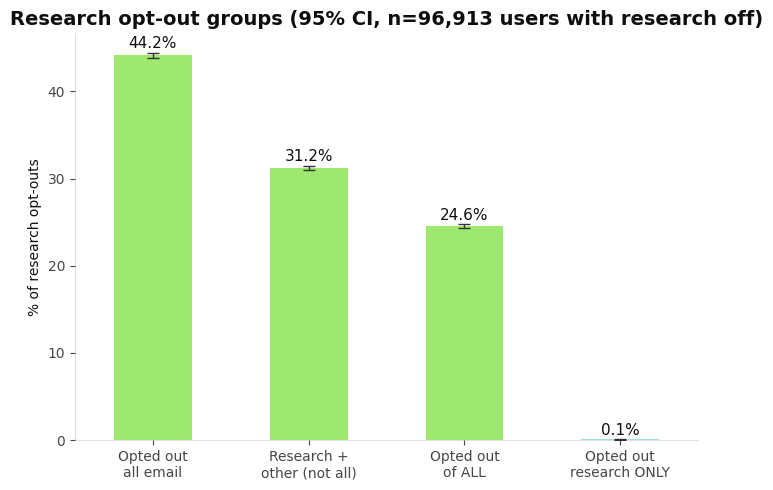

In [7]:
# Chart 2: Opt-out groups (% of users who opted out of research)
surveys_off = ~df['SURVEYS_EMAIL']
n_surveys_off = surveys_off.sum()

group_rates = pd.Series({
    'Opted out\nof ALL': df['opted_out_all'].sum() / n_surveys_off * 100,
    'Opted out\nall email': df['opted_out_all_email'].sum() / n_surveys_off * 100,
    'Research +\nother (not all)': df['opted_out_surveys_plus_but_not_all'].sum() / n_surveys_off * 100,
    'Opted out\nresearch ONLY': df['opted_out_only_surveys'].sum() / n_surveys_off * 100,
})

# 95% CI on each share, denominator = research opt-outs, with finite population correction.
# Population of research opt-outs estimated by scaling sample count by 4M/1M.
N_POP = 4_000_000
samp_frac = len(df) / N_POP
n_pop_off = n_surveys_off / samp_frac
fpc = np.sqrt((n_pop_off - n_surveys_off) / (n_pop_off - 1))
pg = group_rates / 100
ci95 = 1.96 * np.sqrt(pg * (1 - pg) / n_surveys_off) * fpc * 100

group_rates = group_rates.sort_values(ascending=False)
ci95 = ci95.reindex(group_rates.index)

colors = [wise_colours.BRIGHT_BLUE if 'only' in label.lower() else wise_colours.BRIGHT_GREEN
          for label in group_rates.index]

fig, ax = plt.subplots(figsize=(7, 5))
group_rates.plot(kind='bar', ax=ax, color=colors,
                 yerr=ci95.values, capsize=4,
                 error_kw={'ecolor': '#333333', 'elinewidth': 1})
ax.set_ylabel('% of research opt-outs')
ax.set_xlabel('')
ax.set_title(f'Research opt-out groups (95% CI, n={n_surveys_off:,} users with research off)')
for i, v in enumerate(group_rates):
    ax.text(i, v + ci95.iloc[i] + 0.5, f'{v:.1f}%', ha='center', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This is a strong indication that people are going into this page to turn off marketing emails and research gets caught in the crossfire. Without further data, you could argue that the ~30% who choose surveys and other options are being selective and that's a signal of intent. 

But, the opt out of all and opt out of all email (~70% of survey opt outs) are probably a symptom of poor design of the notifications page than actual intent not to give feedback. In other words, the **design of this page might be causing us to lose up to 70% of our potential respondents & participants.** 

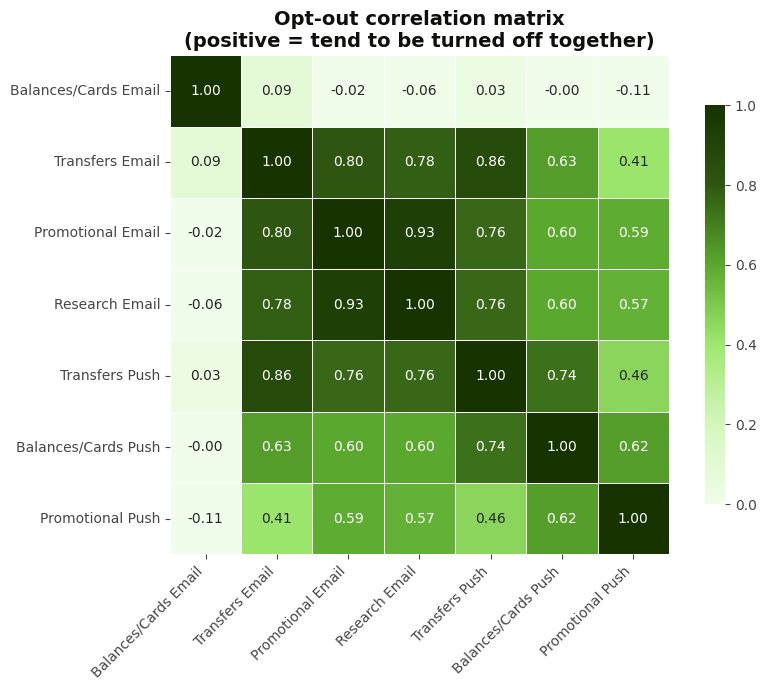

In [7]:
# Correlation matrix: opt-out co-occurrence (excl. Campaigns Email)
heatmap_cols = ['BALANCES_CARDS_EMAIL','TRANSFERS_EMAIL', 'PROMOTIONAL_EMAIL',
                'SURVEYS_EMAIL', 'TRANSFERS_PUSH', 'BALANCES_CARDS_PUSH',
                'PROMOTIONAL_PUSH']
heatmap_labels = ['Balances/Cards Email', 'Transfers Email', 'Promotional Email',
                  'Research Email', 'Transfers Push', 'Balances/Cards Push',
                  'Promotional Push']

opt_out_df = (~df[heatmap_cols]).astype(int)
opt_out_df.columns = heatmap_labels

corr = opt_out_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='wise_green',
            vmin=0, vmax=1, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Opt-out correlation matrix\n(positive = tend to be turned off together)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The email-to-email correlations are higher than email-to-push or push-to-push correlations. That tells you:

People are turning off email channels as a block, not individually. When someone opts out of Promotional Email, they very likely also opt out of Transfers Email, Surveys Email, etc. The push channels don't show the same clustering as they are toggled more independently.

This is consistent with the chart above and the idea that survey research is getting unduly restricted. It suggests there's either:

- A UI pattern that groups email toggles together (or an "unsubscribe all emails" link at the bottom of an email)
- A user mental model of "I don't want emails from Wise" rather than "I don't want to hear about surveys specifically"

Either way, the surveys opt-out is being driven by an anti-email sentiment, not an anti-feedback sentiment.

Given this information there seem to be two things which need to be done:
1) Move the Research Opt-In to a different part of settings. 
- Research is not part of the same mental space as marketing, and being included here is causing inadvertent opt-outs. 
- Solving this problem will ensure that any research opt-outs going forward are true indications of intent to not give feedback

2) Identify a mechanism to give people who have inadvertently opted out a chance to opt back in. This could be coupled with a redesign. The exact mechanism will require some additional research. 

## Ok, opt-out rates are probably inflated due to design. But 20-30% is still < 90% that we often see in Braze. What's going on there?

The above analysis was based on the notifications preferences table, which the CRM tables are built on. It's worth checking to see that the CRM tables and notifications preferences tables line up. 

In [9]:
# Alignment of research_email (NOTIFICATIONS.USER_PREFERENCES) with both CRM tables
import json

def extract_survey_email(raw):
    if pd.isna(raw):
        return None
    try:
        prefs = json.loads(raw)
        # Handle double-encoded JSON
        if isinstance(prefs, str):
            prefs = json.loads(prefs)
        return prefs.get('SURVEYS', {}).get('EMAIL', None)
    except (json.JSONDecodeError, TypeError, AttributeError):
        return None

df['crm_surveys_email'] = df['CRM_LOGGED_PREFS'].apply(extract_survey_email)

research_label = df['SURVEYS_EMAIL'].map(
    {True: 'research_email = True', False: 'research_email = False'})

# Source 1: INT_NOTIFICATION_OPT_OUTS — date stamp present means an opt-out record exists
int_opt = df['SURVEY_OPT_OUT_FROM_INT_NOTIFICATION_OPT_OUTS'].notnull().map(
    {True: 'has opt-out record', False: 'no opt-out record'})
int_tbl = pd.crosstab(research_label, int_opt, normalize='index') * 100

# Source 2: CRM_LOGGED_PREFS — preferences log (RPT_CRM.USER_CHANNELS_PREFERENCES_LOG)
crm_val = df['crm_surveys_email'].map({True: 'CRM = True', False: 'CRM = False', None: 'CRM = null'})
crm_tbl = pd.crosstab(research_label, crm_val, normalize='index') * 100

n_frame = research_label.value_counts().rename('n').to_frame()

combined = pd.concat({
    'n': n_frame,
    'INT_NOTIFICATION_OPT_OUTS': int_tbl,
    'CRM_LOGGED_PREFS (prefs log)': crm_tbl,
}, axis=1).reindex(['research_email = True', 'research_email = False'])

fmt = {col: '{:.1f}%' for col in combined.columns if col[0] != 'n'}
fmt[('n', 'n')] = '{:,.0f}'
combined.index.name = None
combined.style.format(fmt).set_caption(
    'research_email alignment across both CRM tables (row %)')

The CRM tables are aligned with the notifications preferences, so the gap between what the preferences show and the braze opt outs must be coming from somewhere else. 

## Global Experimentation Framework

Braze also pulls from the global experimentation framework to process exclusions. Users must be in the "treatment" condition to qualify for an survey.

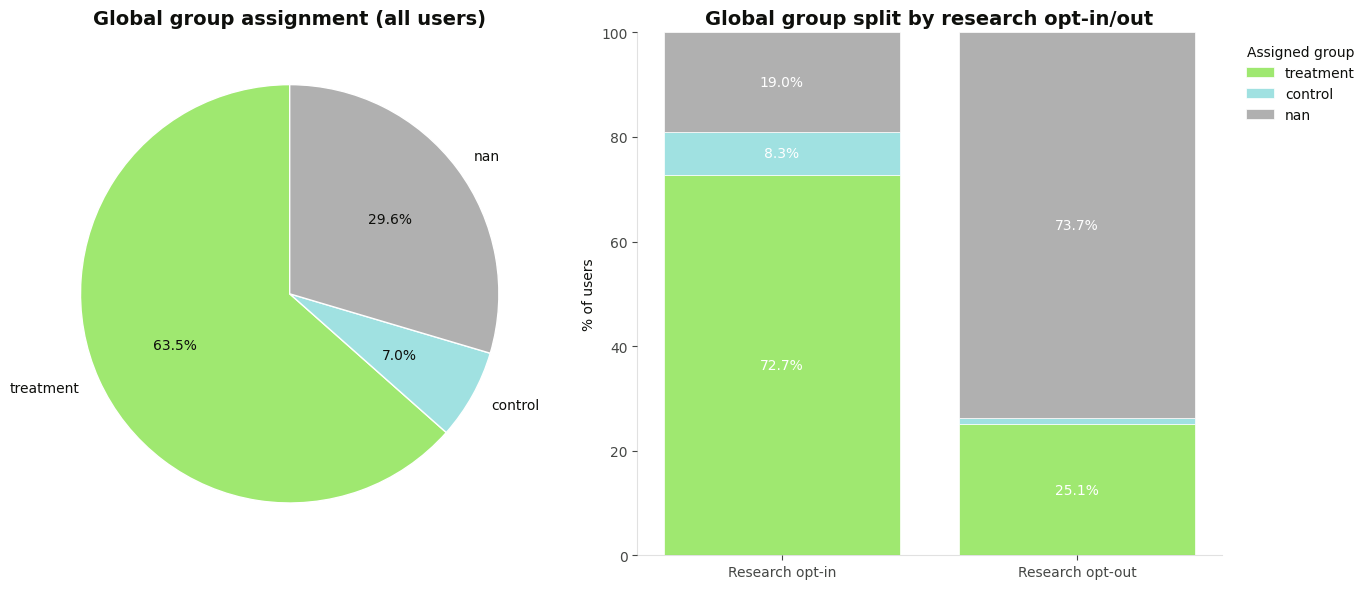

In [11]:
# Chart 3: Global group assignment — overall split + by research opt-in/out
group = df['ASSIGNED_GLOBAL_GROUP'].fillna('nan')
order = ['treatment', 'control', 'nan']
group_colors = {
    'treatment': wise_colours.BRIGHT_GREEN,
    'control': wise_colours.BRIGHT_BLUE,
    'nan': '#B0B0B0',
}
colors = [group_colors[g] for g in order]

fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: pie of overall group assignment ---
pie_counts = group.value_counts().reindex(order).fillna(0)
ax_pie.pie(pie_counts, labels=order, colors=colors, autopct='%1.1f%%',
           startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax_pie.set_title('Global group assignment (all users)')

# --- Right: stacked bar, group split within research opt-in vs opt-out ---
opt_label = df['SURVEYS_EMAIL'].map({True: 'Research opt-in', False: 'Research opt-out'})
share = pd.crosstab(opt_label, group, normalize='index')[order] * 100
share = share.reindex(['Research opt-in', 'Research opt-out'])

bottom = np.zeros(len(share))
for g in order:
    ax_bar.bar(share.index, share[g], bottom=bottom, color=group_colors[g],
               label=g, edgecolor='white', linewidth=0.5)
    for i, v in enumerate(share[g]):
        if v > 2:
            ax_bar.text(i, bottom[i] + v / 2, f'{v:.1f}%', ha='center',
                        va='center', fontsize=10, color='white')
    bottom += share[g].values

ax_bar.set_ylabel('% of users')
ax_bar.set_ylim(0, 100)
ax_bar.set_title('Global group split by research opt-in/out')
ax_bar.legend(title='Assigned group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

This accounts for a substantial drop of eligible users out of the opted in pool. 

~10% of opted-in users will not be eligible for a study due to assignment to the control. 

~20% of opted-in users will not be eligible due to not being assigned to a group at all. This can disproportionately impact your study if you are studying a group that aligns with one of the reasons they may not be assigned.

Of note:
- Users are not assigned until they are 30 - 40 days old. If your target audience includes new users, you will be disproportionately impacted
- Users who opt out of promotional emails are automatically not assigned. As shown above, many users may be opting out of promotional emails and research emails at the same time inadvertently, putting them forever into unassigned group. **If they ever at a later date opt IN to research emails, we would never be able to respect that intent as the assignment will never change.**


## Is it reasonable to exclude research outreach based on the global experimentaiton framework?

No, it's not. 

The purpose of the global experimentation framework is to "provide the high level view of channel-level performance of CRM."

Research outreach shouldn't be subject to this filter, and CRM has confirmed this to be the case. But by default, the experimentation framework "treatment" group filter was applied as part of the "key-email-subjects" exclusion. 

This has now been resolved. Going forward, if you see inexplicably large drop offs in the Braze filtering, confirming whether this filter is active is one of the first things you should check. 

## Global Cooldowns

By default Braze will not send to users if they are in a cooldown period - i.e., within 30 days of receiving another outreach.

This is methodologically a good thing - if we reach out to users too frequently, this can lead to bad side effects including opt-outs, unsubscribes, and poor response rates. 

In the current implementation, research surveys are grouped in with marketing outreach. So if a user received a marketing outreach they would be ineligible to be contacted by research for at least 30 days afterwards. 

The impact on this on research availability is below.


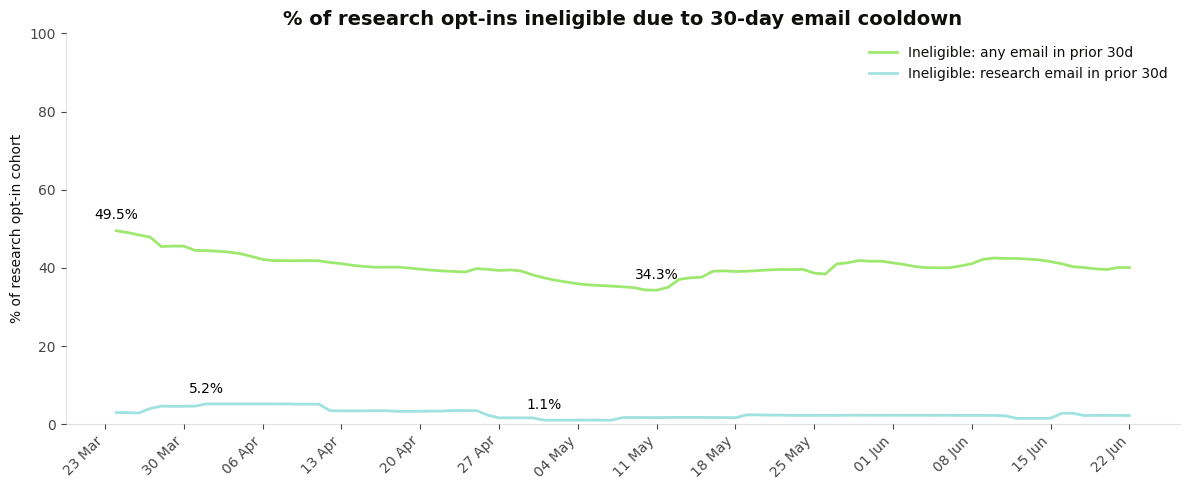

In [16]:
# Chart 4: % of research opt-ins hit by 30-day cooldown
df_eligible = pd.read_csv('/Users/bryan.carroll/Library/CloudStorage/GoogleDrive-bryan.carroll@wise.com/My Drive/BryWise/1_Projects/Quick Analysis on Survey Opt In/Research eligibility cooldown_2026-06-22-1153.csv')
df_eligible['DAY'] = pd.to_datetime(df_eligible['DAY'])

fig, ax = plt.subplots(figsize=(12, 5))

lines = [
    ('PCT_INELIGIBLE_ANY_EMAIL', wise_colours.BRIGHT_GREEN, 'Ineligible: any email in prior 30d'),
    ('PCT_INELIGIBLE_RESEARCH',  wise_colours.BRIGHT_BLUE,  'Ineligible: research email in prior 30d'),
]

for col, color, label in lines:
    series = df_eligible[col]
    ax.plot(df_eligible['DAY'], series, color=color, linewidth=2, label=label)

    for idx in [series.idxmax(), series.idxmin()]:
        x = df_eligible.loc[idx, 'DAY']
        y = series[idx]
        ax.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 6),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=10, color='black')

ax.set_ylabel('% of research opt-in cohort')
ax.set_xlabel('')
ax.set_title('% of research opt-ins ineligible due to 30-day email cooldown')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=10)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The question of whether or not it is reasonable to group research outreach into the same cooldown channels as marketing outreach is a businesses decision, which should be evaluated. 

As it stands, on any given day, research loses between ~35 - 50% of eligible respondents due to cooldown eligibility from having received any email in the last 30 days. Only 1-5% of those were due to prior research outreach.

In theory, these are coming from different sources (Wise Research vs Wise) and occupy a different space in users' minds. We need to explore whether research email has similar effects on unsubscribe rates from marketing outreach as marketing outreach does. Experience from other businesesses would say that this is not the case, and we should confirm that Wise is the outlier to justify maintaining this grouping. 